# Deep Learning Models - Training & Testing (Dynamic Dataset Control)
## Network Intrusion Detection System

### Features:
- **Per-model dataset size control** - Set different sample sizes for each model
- **Model-specific directories** - Each model saves to its own subdirectory
- **Memory-efficient chunked loading**
- **Separate scalers per model**

### Models:
1. CNN (Convolutional Neural Network)
2. LSTM (Long Short-Term Memory)

## 1️⃣ Import Libraries

In [6]:
import pandas as pd
import numpy as np
import time
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import (Dense, Dropout, Conv1D, MaxPooling1D, Flatten,
                          LSTM, BatchNormalization)
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from keras.optimizers import Adam

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os

# Set seeds
np.random.seed(42)
tf.random.set_seed(42)

print("✅ All libraries imported successfully!")
print(f"\n🔧 TensorFlow version: {tf.__version__}")
print(f"🖥️ GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

✅ All libraries imported successfully!

🔧 TensorFlow version: 2.20.0
🖥️ GPU available: False


## 2️⃣ Configuration

In [7]:
# ========================================
# CONFIGURATION
# ========================================

INPUT_FILE = "archive/full_df_binary_labels.csv"
BASE_MODEL_DIR = "trained_models/dl/"

# Data loading settings
CHUNK_SIZE = 100000  # Load 100K rows at a time
MAX_ROWS = None      # None = load all data, or set limit
TEST_SIZE = 0.2
VALIDATION_SPLIT = 0.2
RANDOM_STATE = 42
SAVE_MODELS = True

# Training parameters
EPOCHS = 10
BATCH_SIZE = 256
PATIENCE = 10

# ========================================
# PER-MODEL DATASET SIZE CONTROL
# ========================================
# Set the number of rows to use for each model
# None = use full dataset
# Integer = use that many rows (will be sampled from full dataset)

MODEL_SAMPLE_SIZES = {
    'CNN': 1000000,          # Use full dataset
    'LSTM': 100000,       # LSTM is slow, use 200k rows
}

# You can also customize training params per model
MODEL_EPOCHS = {
    'CNN': 20,
    'LSTM': 15,  # Fewer epochs for LSTM to save time
}

MODEL_BATCH_SIZES = {
    'CNN': 256,
    'LSTM': 512,  # Larger batch for LSTM to speed up
}

print("📊 Per-Model Configuration:")
for model in MODEL_SAMPLE_SIZES.keys():
    size_str = 'Full dataset' if MODEL_SAMPLE_SIZES[model] is None else f'{MODEL_SAMPLE_SIZES[model]:,} rows'
    print(f"   {model}:")
    print(f"      - Sample Size: {size_str}")
    print(f"      - Epochs: {MODEL_EPOCHS[model]}")
    print(f"      - Batch Size: {MODEL_BATCH_SIZES[model]}")

# Create base directory
os.makedirs(BASE_MODEL_DIR, exist_ok=True)
print(f"\n✅ Base model directory: {BASE_MODEL_DIR}")

📊 Per-Model Configuration:
   CNN:
      - Sample Size: 1,000,000 rows
      - Epochs: 20
      - Batch Size: 256
   LSTM:
      - Sample Size: 100,000 rows
      - Epochs: 15
      - Batch Size: 512

✅ Base model directory: trained_models/dl/


## 3️⃣ Load Data (Chunk by Chunk - Memory Safe!)

In [8]:
print("📂 Loading dataset in chunks (memory-safe)...\n")

# Initialize lists to store chunks
chunks = []
total_rows = 0

# Read in chunks
print("⏳ Reading data...")
for i, chunk in enumerate(pd.read_csv(INPUT_FILE, chunksize=CHUNK_SIZE)):
    # Check if we've reached max rows
    if MAX_ROWS and total_rows >= MAX_ROWS:
        break
    
    # If this chunk would exceed MAX_ROWS, truncate it
    if MAX_ROWS and total_rows + len(chunk) > MAX_ROWS:
        chunk = chunk.head(MAX_ROWS - total_rows)
    
    chunks.append(chunk)
    total_rows += len(chunk)
    
    # Progress update every 5 chunks
    if (i + 1) % 5 == 0:
        print(f"   Loaded chunk {i+1}: {total_rows:,} rows total")

print(f"\n✅ Loaded {len(chunks)} chunks")
print(f"✅ Total rows: {total_rows:,}")

# Combine chunks
print("\n🔗 Combining chunks...")
df_full = pd.concat(chunks, ignore_index=True)
del chunks  # Free memory

print(f"✅ Dataset shape: {df_full.shape}")
print(f"✅ Columns: {len(df_full.columns)}")
print(f"\nFirst few columns: {list(df_full.columns)[:5]}")

📂 Loading dataset in chunks (memory-safe)...

⏳ Reading data...
   Loaded chunk 5: 500,000 rows total
   Loaded chunk 10: 1,000,000 rows total
   Loaded chunk 15: 1,500,000 rows total
   Loaded chunk 20: 2,000,000 rows total
   Loaded chunk 25: 2,500,000 rows total
   Loaded chunk 30: 3,000,000 rows total
   Loaded chunk 35: 3,500,000 rows total
   Loaded chunk 40: 4,000,000 rows total
   Loaded chunk 45: 4,500,000 rows total
   Loaded chunk 50: 5,000,000 rows total
   Loaded chunk 55: 5,500,000 rows total
   Loaded chunk 60: 6,000,000 rows total
   Loaded chunk 65: 6,500,000 rows total
   Loaded chunk 70: 7,000,000 rows total
   Loaded chunk 75: 7,500,000 rows total
   Loaded chunk 80: 8,000,000 rows total
   Loaded chunk 85: 8,500,000 rows total
   Loaded chunk 90: 9,000,000 rows total
   Loaded chunk 95: 9,500,000 rows total
   Loaded chunk 100: 10,000,000 rows total
   Loaded chunk 105: 10,500,000 rows total
   Loaded chunk 110: 11,000,000 rows total
   Loaded chunk 115: 11,500,000

## 4️⃣ Data Overview

In [9]:
# Display first few rows
print("📊 First 5 rows:")
display(df_full.head())

# Memory usage
print(f"\n💾 Memory usage: {df_full.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Data info
print("\n📋 Dataset Info:")
print(f"   Shape: {df_full.shape}")
print(f"   Columns: {len(df_full.columns)}")
print(f"   Data types: {df_full.dtypes.value_counts().to_dict()}")

📊 First 5 rows:


,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Mean,Fwd Pkt Len Std,...,Subflow Bwd Byts,Init Fwd Win Byts,Init Bwd Win Byts,Fwd Act Data Pkts,Fwd Seg Size Min,Idle Mean,Idle Max,Idle Min,Label,Label_Binary
0,0,0,112641719,3,0,0.0,0.0,0.0,0.000000,0.000000,...,0,-1,-1,0,0,56320859.5,56320958.0,56320761.0,Benign,0
1,0,0,112641466,3,0,0.0,0.0,0.0,0.000000,0.000000,...,0,-1,-1,0,0,56320733.0,56320814.0,56320652.0,Benign,0
2,0,0,112638623,3,0,0.0,0.0,0.0,0.000000,0.000000,...,0,-1,-1,0,0,56319311.5,56319525.0,56319098.0,Benign,0
3,22,6,6453966,15,10,1239.0,2273.0,744.0,82.600000,196.741237,...,2273,65535,233,6,32,0.0,0.0,0.0,Benign,0
4,22,6,8804066,14,11,1143.0,2209.0,744.0,81.642857,203.745545,...,2209,5808,233,6,32,0.0,0.0,0.0,Benign,0



💾 Memory usage: 8184.55 MB

📋 Dataset Info:
   Shape: (16232943, 59)
   Columns: 59
   Data types: {dtype('float64'): 37, dtype('int64'): 21, dtype('O'): 1}


📊 Class Distribution:
Label
Benign                      13484708
DDOS attack-HOIC              686012
DDoS attacks-LOIC-HTTP        576191
DoS attacks-Hulk              461912
Bot                           286191
FTP-BruteForce                193360
SSH-Bruteforce                187589
Infilteration                 161934
DoS attacks-SlowHTTPTest      139890
DoS attacks-GoldenEye          41508
DoS attacks-Slowloris          10990
DDOS attack-LOIC-UDP            1730
Brute Force -Web                 611
Brute Force -XSS                 230
SQL Injection                     87
Name: count, dtype: int64


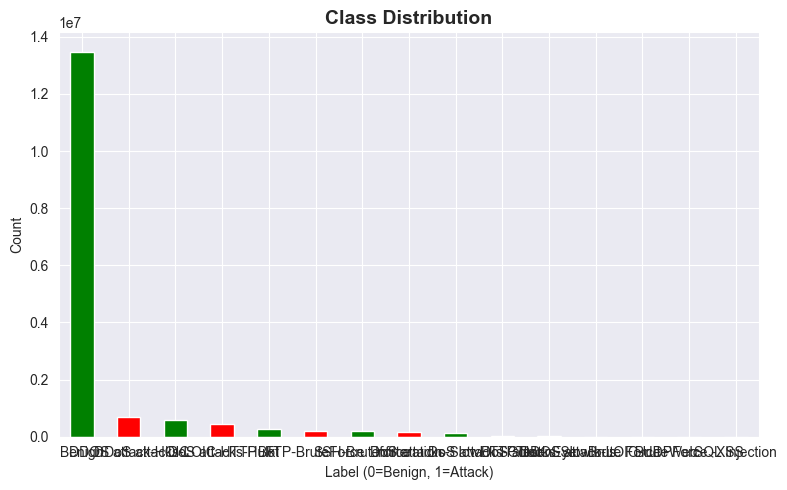


  Benign (0): 13,484,708 (83.07%)
  Attack (1): 2,748,235 (16.93%)


In [10]:
# Class distribution
print("📊 Class Distribution:")
class_counts = df_full['Label'].value_counts()
print(class_counts)

# Visualize
plt.figure(figsize=(8, 5))
class_counts.plot(kind='bar', color=['green', 'red'])
plt.title('Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Label (0=Benign, 1=Attack)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Percentages
benign_count = (df_full['Label_Binary'] == 0).sum()
attack_count = (df_full['Label_Binary'] == 1).sum()
benign_pct = benign_count / len(df_full) * 100
attack_pct = attack_count / len(df_full) * 100

print(f"\n  Benign (0): {benign_count:,} ({benign_pct:.2f}%)")
print(f"  Attack (1): {attack_count:,} ({attack_pct:.2f}%)")

## 5️⃣ Prepare Full Dataset

In [11]:
print("🔧 Preparing data...")

# Separate features and labels
df_full = df_full.drop(['Label'], axis=1)
X_full = df_full.drop(['Label_Binary'], axis=1)
y_full = df_full['Label_Binary']

# Keep only numeric columns
print("\n🔢 Selecting numeric features...")
X_full = X_full.select_dtypes(include=[np.number])

print(f"\n✅ Features shape: {X_full.shape}")
print(f"✅ Labels shape: {y_full.shape}")
print(f"\nNumber of features: {X_full.shape[1]}")

# Free memory
del df_full
print("\n🧹 Freed original dataframe memory")

🔧 Preparing data...

🔢 Selecting numeric features...

✅ Features shape: (16232943, 57)
✅ Labels shape: (16232943,)

Number of features: 57

🧹 Freed original dataframe memory


## 6️⃣ Helper Functions

In [12]:
# ========================================
# HELPER FUNCTION: SAMPLE DATA FOR MODEL
# ========================================

def get_model_data(X_full, y_full, model_name, sample_size, test_size, random_state):
    """
    Get train/test split for a specific model with optional sampling.
    Returns scaled data ready for DL models.
    """
    
    if sample_size is None:
        # Use full dataset
        X = X_full
        y = y_full
        print(f"📊 Using FULL dataset: {len(X):,} rows")
    else:
        # Sample dataset
        if sample_size > len(X_full):
            print(f"⚠️  Requested {sample_size:,} rows but only {len(X_full):,} available")
            print(f"📊 Using full dataset instead")
            X = X_full
            y = y_full
        else:
            print(f"📊 Sampling {sample_size:,} rows from {len(X_full):,} total (stratified)")
            # Stratified sampling to maintain class distribution
            X, _, y, _ = train_test_split(
                X_full, y_full,
                train_size=sample_size,
                random_state=random_state,
                stratify=y_full
            )
    
    # Train-test split
    print(f"🔪 Splitting into train/test ({test_size*100}% test)...")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )
    
    print(f"✅ Train set: {X_train.shape[0]:,} samples")
    print(f"✅ Test set: {X_test.shape[0]:,} samples")
    
    # Scale data
    print(f"⚖️  Scaling features...")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    print("✅ Features scaled")
    
    return X_train_scaled, X_test_scaled, y_train, y_test, scaler


# ========================================
# MODEL BUILDERS
# ========================================

def build_cnn_model(input_shape):
    """Build CNN model for intrusion detection"""
    model = Sequential([
        # Input layer needs to reshape for Conv1D
        keras.layers.Reshape((input_shape, 1), input_shape=(input_shape,)),
        
        # Conv Block 1
        Conv1D(64, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),
        
        # Conv Block 2
        Conv1D(128, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),
        
        # Conv Block 3
        Conv1D(256, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.4),
        
        # Flatten and Dense layers
        Flatten(),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(64, activation='relu'),
        Dropout(0.3),
        
        # Output layer
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
    )
    
    return model


def build_lstm_model(input_shape):
    """Build LSTM model for intrusion detection"""
    model = Sequential([
        # Input layer needs to reshape for LSTM
        keras.layers.Reshape((input_shape, 1), input_shape=(input_shape,)),
        
        # LSTM layers
        LSTM(128, return_sequences=True),
        BatchNormalization(),
        Dropout(0.3),
        
        LSTM(64, return_sequences=False),
        BatchNormalization(),
        Dropout(0.3),
        
        # Dense layers
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(32, activation='relu'),
        Dropout(0.3),
        
        # Output layer
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
    )
    
    return model


print("✅ Helper functions defined")

✅ Helper functions defined


## 7️⃣ Train Models

In [13]:
# ========================================
# TRAIN ALL MODELS
# ========================================

# Model builders
model_builders = {
    'CNN': build_cnn_model,
    'LSTM': build_lstm_model
}

results = {}
histories = {}

for model_name, builder_func in model_builders.items():
    print("\n" + "="*80)
    print(f"🚀 TRAINING: {model_name}")
    print("="*80)
    
    # Create model-specific directory
    model_dir = os.path.join(BASE_MODEL_DIR, model_name.lower(), '')
    os.makedirs(model_dir, exist_ok=True)
    print(f"📁 Model directory: {model_dir}")
    
    # Get model-specific configuration
    sample_size = MODEL_SAMPLE_SIZES.get(model_name)
    epochs = MODEL_EPOCHS.get(model_name, EPOCHS)
    batch_size = MODEL_BATCH_SIZES.get(model_name, BATCH_SIZE)
    
    print(f"\n⚙️  Model Configuration:")
    print(f"   Epochs: {epochs}")
    print(f"   Batch Size: {batch_size}")
    print(f"   Patience: {PATIENCE}")
    print()
    
    # Get train/test data with optional sampling
    X_train, X_test, y_train, y_test, scaler = get_model_data(
        X_full, y_full,
        model_name,
        sample_size,
        TEST_SIZE,
        RANDOM_STATE
    )
    
    # Save scaler
    if SAVE_MODELS:
        scaler_path = os.path.join(model_dir, 'scaler.pkl')
        with open(scaler_path, 'wb') as f:
            pickle.dump(scaler, f)
        print(f"💾 Scaler saved: {scaler_path}")
    
    # Build model
    print(f"\n🏗️  Building {model_name} model...")
    model = builder_func(X_train.shape[1])
    
    # Print model summary
    print(f"\n📋 Model Architecture:")
    model.summary()
    
    # Callbacks
    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=PATIENCE,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-7,
            verbose=1
        ),
        ModelCheckpoint(
            os.path.join(model_dir, 'best_model.keras'),
            monitor='val_loss',
            save_best_only=True,
            verbose=1
        )
    ]
    
    # Training
    print(f"\n⏱️  Training...")
    start_time = time.time()
    
    history = model.fit(
        X_train, y_train,
        validation_split=VALIDATION_SPLIT,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1
    )
    
    train_time = time.time() - start_time
    print(f"\n✅ Training completed in {train_time:.2f} seconds ({train_time/60:.2f} minutes)")
    
    # Evaluation
    print(f"\n🔮 Evaluating on test set...")
    start_time = time.time()
    
    # Get predictions
    y_pred_proba = model.predict(X_test, batch_size=batch_size, verbose=0)
    y_pred = (y_pred_proba > 0.5).astype(int).flatten()
    
    pred_time = time.time() - start_time
    print(f"✅ Predictions completed in {pred_time:.2f} seconds")
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='binary')
    recall = recall_score(y_test, y_pred, average='binary')
    f1 = f1_score(y_test, y_pred, average='binary')
    cm = confusion_matrix(y_test, y_pred)
    
    # Store results
    results[model_name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'train_time': train_time,
        'pred_time': pred_time,
        'confusion_matrix': cm,
        'predictions': y_pred,
        'sample_size': len(X_train) + len(X_test),
        'train_samples': len(X_train),
        'test_samples': len(X_test),
        'epochs_trained': len(history.history['loss'])
    }
    
    histories[model_name] = history
    
    # Print metrics
    print(f"\n📊 RESULTS:")
    print(f"   Accuracy:  {accuracy:.4f}")
    print(f"   Precision: {precision:.4f}")
    print(f"   Recall:    {recall:.4f}")
    print(f"   F1-Score:  {f1:.4f}")
    
    print(f"\n🕐 TIME:")
    print(f"   Train: {train_time:.2f}s ({train_time/60:.2f} min)")
    print(f"   Test:  {pred_time:.2f}s")
    
    print(f"\n🎯 Confusion Matrix:")
    print(cm)
    
    # Save final model
    if SAVE_MODELS:
        model_path = os.path.join(model_dir, 'final_model.keras')
        model.save(model_path)
        print(f"\n💾 Final model saved: {model_path}")
        
        # Save history
        history_path = os.path.join(model_dir, 'history.pkl')
        with open(history_path, 'wb') as f:
            pickle.dump(history.history, f)
        print(f"💾 Training history saved: {history_path}")
        
        # Save metadata
        metadata = {
            'model_name': model_name,
            'sample_size': sample_size,
            'train_samples': len(X_train),
            'test_samples': len(X_test),
            'features': X_train.shape[1],
            'epochs': epochs,
            'epochs_trained': len(history.history['loss']),
            'batch_size': batch_size,
            'train_time': train_time,
            'metrics': {
                'accuracy': accuracy,
                'precision': precision,
                'recall': recall,
                'f1_score': f1
            }
        }
        
        metadata_path = os.path.join(model_dir, 'metadata.pkl')
        with open(metadata_path, 'wb') as f:
            pickle.dump(metadata, f)
        print(f"💾 Metadata saved: {metadata_path}")

print("\n" + "="*80)
print("✅ ALL MODELS TRAINED & TESTED!")
print("="*80)


🚀 TRAINING: CNN
📁 Model directory: trained_models/dl/cnn\

⚙️  Model Configuration:
   Epochs: 20
   Batch Size: 256
   Patience: 10

📊 Sampling 1,000,000 rows from 16,232,943 total (stratified)
🔪 Splitting into train/test (20.0% test)...
✅ Train set: 800,000 samples
✅ Test set: 200,000 samples
⚖️  Scaling features...
✅ Features scaled
💾 Scaler saved: trained_models/dl/cnn\scaler.pkl

🏗️  Building CNN model...

📋 Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 57, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 57, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 57, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 28, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 28, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 14, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 14, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 7, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 7, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1792)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       229,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 363,649 (1.39 MB)

 Trainable params: 362,497 (1.38 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_1 (Reshape)             │ (None, 57, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 57, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 57, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 57, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,265 (481.50 KB)

 Trainable params: 122,753 (479.50 KB)

 Non-trainable params: 512 (2.00 KB)


⏱️  Training...
Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.7697 - loss: 0.4770 - precision_1: 0.4221 - recall_1: 0.6151
Epoch 1: val_loss improved from None to 0.50548, saving model to trained_models/dl/lstm\best_model.keras

Epoch 1: finished saving model to trained_models/dl/lstm\best_model.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 27s 194ms/step - accuracy: 0.8600 - loss: 0.3418 - precision_1: 0.5782 - recall_1: 0.6422 - val_accuracy: 0.8344 - val_loss: 0.5055 - val_precision_1: 0.9630 - val_recall_1: 0.0193 - learning_rate: 0.0010
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.9402 - loss: 0.1984 - precision_1: 0.8445 - recall_1: 0.7881
Epoch 2: val_loss did not improve from 0.50548
125/125 ━━━━━━━━━━━━━━━━━━━━ 23s 187ms/step - accuracy: 0.9435 - loss: 0.1924 - precision_1: 0.8638 - recall_1: 0.7910 - val_accuracy: 0.8292 - val_loss: 0.5343 - val_precision_1: 0.3910 - val_recall_1: 0.0226 - learning_rate: 0.0010
Epoch 3/15
125/125 ━━━━━━━━━━━

## 8️⃣ Performance Summary

In [14]:
# Create summary DataFrame
summary_data = []
for model_name, metrics in results.items():
    summary_data.append({
        'Model': model_name,
        'Sample Size': metrics['sample_size'],
        'Train Samples': metrics['train_samples'],
        'Test Samples': metrics['test_samples'],
        'Epochs': metrics['epochs_trained'],
        'Accuracy': metrics['accuracy'],
        'Precision': metrics['precision'],
        'Recall': metrics['recall'],
        'F1-Score': metrics['f1_score'],
        'Train Time (min)': metrics['train_time'] / 60,
        'Test Time (s)': metrics['pred_time']
    })

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print("📊 PERFORMANCE SUMMARY (sorted by F1-Score):")
print("="*100)
display(summary_df.style.background_gradient(
    subset=['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    cmap='RdYlGn'
))

# Save summary
if SAVE_MODELS:
    summary_path = os.path.join(BASE_MODEL_DIR, 'training_summary.csv')
    summary_df.to_csv(summary_path, index=False)
    print(f"\n💾 Summary saved to {summary_path}")

📊 PERFORMANCE SUMMARY (sorted by F1-Score):


,Model,Sample Size,Train Samples,Test Samples,Epochs,Accuracy,Precision,Recall,F1-Score,Train Time (min),Test Time (s)
0,CNN,1000000,800000,200000,20,0.989125,0.995527,0.939988,0.966961,18.000112,4.132482
1,LSTM,100000,80000,20000,15,0.986650,0.987801,0.932664,0.959441,5.314867,2.891747



💾 Summary saved to trained_models/dl/training_summary.csv


## 9️⃣ Training History Visualization

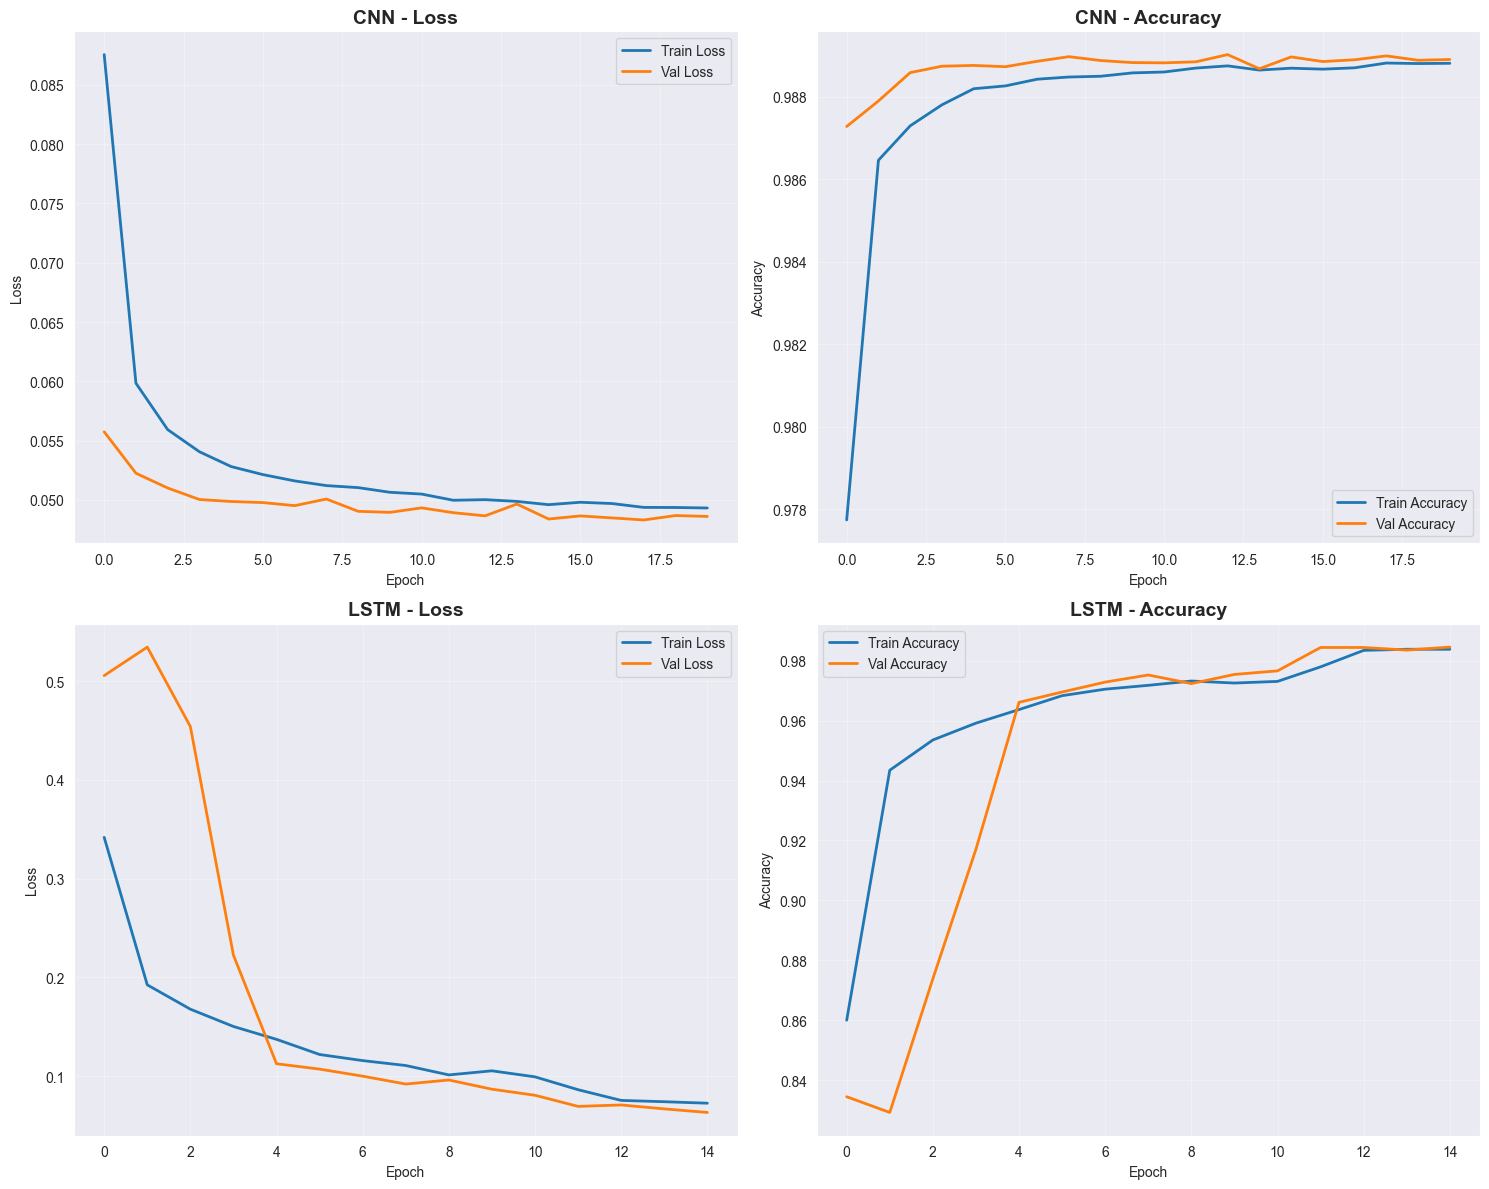


💾 Training history plot saved to trained_models/dl/training_history.png


In [15]:
# Plot training histories
fig, axes = plt.subplots(len(histories), 2, figsize=(15, 6*len(histories)))
if len(histories) == 1:
    axes = axes.reshape(1, -1)

for idx, (model_name, history) in enumerate(histories.items()):
    # Loss
    axes[idx, 0].plot(history.history['loss'], label='Train Loss', linewidth=2)
    axes[idx, 0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    axes[idx, 0].set_title(f'{model_name} - Loss', fontsize=14, fontweight='bold')
    axes[idx, 0].set_xlabel('Epoch')
    axes[idx, 0].set_ylabel('Loss')
    axes[idx, 0].legend()
    axes[idx, 0].grid(True, alpha=0.3)
    
    # Accuracy
    axes[idx, 1].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    axes[idx, 1].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
    axes[idx, 1].set_title(f'{model_name} - Accuracy', fontsize=14, fontweight='bold')
    axes[idx, 1].set_xlabel('Epoch')
    axes[idx, 1].set_ylabel('Accuracy')
    axes[idx, 1].legend()
    axes[idx, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{BASE_MODEL_DIR}training_history.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"\n💾 Training history plot saved to {BASE_MODEL_DIR}training_history.png")

## 🔟 Confusion Matrices

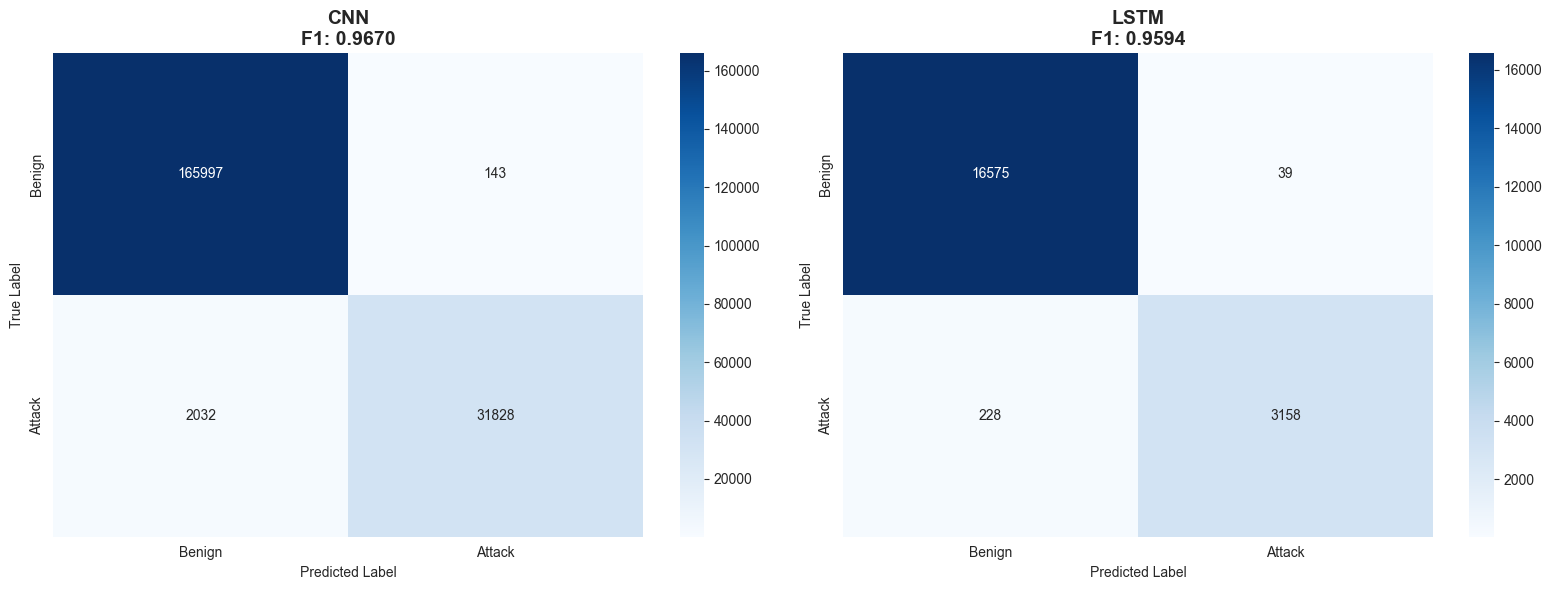


💾 Confusion matrices saved to trained_models/dl/confusion_matrices.png


In [16]:
# Plot confusion matrices
fig, axes = plt.subplots(1, len(results), figsize=(8*len(results), 6))
if len(results) == 1:
    axes = [axes]

for idx, (model_name, metrics) in enumerate(results.items()):
    cm = metrics['confusion_matrix']
    
    # Create heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                ax=axes[idx], cbar=True,
                xticklabels=['Benign', 'Attack'],
                yticklabels=['Benign', 'Attack'])
    
    axes[idx].set_title(f'{model_name}\nF1: {metrics["f1_score"]:.4f}',
                        fontweight='bold', fontsize=14)
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig(f"{BASE_MODEL_DIR}confusion_matrices.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"\n💾 Confusion matrices saved to {BASE_MODEL_DIR}confusion_matrices.png")

## 1️⃣1️⃣ Final Summary

In [17]:
print("\n" + "="*80)
print("🎉 TRAINING COMPLETE!")
print("="*80)

print("\n📊 Models Ranked by F1-Score:")
for idx, row in summary_df.iterrows():
    print(f"   {idx+1}. {row['Model']}: {row['F1-Score']:.4f} "
          f"(trained on {row['Sample Size']:,} samples in {row['Train Time (min)']:.2f} min)")

print(f"\n📁 All models saved to: {BASE_MODEL_DIR}")
print("\n📁 Directory structure:")
for model_name in model_builders.keys():
    model_dir = model_name.lower()
    print(f"   {BASE_MODEL_DIR}{model_dir}/")
    print(f"      ├── best_model.keras (best model during training)")
    print(f"      ├── final_model.keras (final model)")
    print(f"      ├── scaler.pkl (feature scaler)")
    print(f"      ├── history.pkl (training history)")
    print(f"      └── metadata.pkl (model metadata)")

print("\n" + "="*80)


🎉 TRAINING COMPLETE!

📊 Models Ranked by F1-Score:
   1. CNN: 0.9670 (trained on 1,000,000 samples in 18.00 min)
   2. LSTM: 0.9594 (trained on 100,000 samples in 5.31 min)

📁 All models saved to: trained_models/dl/

📁 Directory structure:
   trained_models/dl/cnn/
      ├── best_model.keras (best model during training)
      ├── final_model.keras (final model)
      ├── scaler.pkl (feature scaler)
      ├── history.pkl (training history)
      └── metadata.pkl (model metadata)
   trained_models/dl/lstm/
      ├── best_model.keras (best model during training)
      ├── final_model.keras (final model)
      ├── scaler.pkl (feature scaler)
      ├── history.pkl (training history)
      └── metadata.pkl (model metadata)

